In [ ]:
# 1. Імпорт основних бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns

from google.colab import drive

# 2. Підключення до Google Drive
drive.mount("/content/drive")

# 3. Перехід у робочу папку з домашнім завданням
%cd /content/drive/MyDrive/Mate_homework/final_project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate_homework/final_project


# Data overview (Огляд даних)

**Первинний аналіз структури даних**

На цьому етапі проводиться завантаження сирих даних та перевірка їхньої цілісності. Основна мета - виявити типи даних, наявність пропусків та аномалій, які потребуватимуть виправлення.

*  ** The "events.csv" table:**

Order ID - order identifier

Order Date - order date

Ship Date - shipment date

Order Priority - order priority

Country Code - 3-letter country code

Product ID - product identifier

Sales Channel - sales channel (Online/Offline)

Units Sold - number of units sold

Unit Price - price per unit

Unit Cost - cost per unit


*  **The "products.csv" table:**

id - product identifier

item_type - product category


*   **The "countries.csv" table:**

name - country name

alpha-2 - 2-letter country code

alpha-3 - 3-letter country code

region - region

sub-region - subregion

**Спільні стовпці в таблицях для подальшого об'єднання**

Для об'єднання таблиць необхідно використати Product ID з events та id з products, щоб додати категорії товарів.

Далі поєднаємо Country Code з events та alpha-3 з countries, щоб отримати географічні дані для аналізу регіонів.

### countries.csv

In [ ]:
# Завантаження довідника країн
countries = pd.read_csv("countries.csv")

# Попередній перегляд перших 5 рядків
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
# Виведення розмірності (рядки, колонки)
print(f"Розмірність таблиці: {countries.shape}")
print("-" * 30)

# Загальна технічна інформація про типи даних та пропуски
countries.info()
print("-" * 30)

# Детальна перевірка типів даних
print("Типи даних по стовпцях:")
print(countries.dtypes)

Розмірність таблиці: (249, 5)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
------------------------------
Типи даних по стовпцях:
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


**Огляд таблиці countries**

*   Структура таблиці:

Таблиця містить 249 записів та 5 колонок. Всі колонки розпізнані як тип object (текстові), що є коректним для назв країн та кодів регіонів.

*   Якість даних:

Попередній огляд через .info() показав, що таблиця країн майже повна, проте є поодинокі пропуски (у колонках alpha-2, region та sub-region), які потребуватимуть уваги на наступному етапі очищення.











###products.csv

In [ ]:
# Завантаження класифікатора товарів
products = pd.read_csv("products.csv")

# Виведення технічних характеристик
print(f"Розмірність таблиці: {products.shape}")
print("-" * 30)

products.info()
print("-" * 30)

# Перегляд доступних категорій
products.head()

Розмірність таблиці: (12, 2)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
------------------------------


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


**Огляд таблиці products**

*  Структура таблиці:

Таблиця містить 12 записів та 2 колонки. Колонка id розпізнана як int64 (ціле число), item_type - як object (рядок)

*   Якість даних:

Усі 12 записів є повними (non-null), що полегшить об'єднання з основною таблицею подій без втрати інформації про категорії.

###events.csv

In [ ]:
# Завантаження основного масиву даних
events = pd.read_csv("events.csv")

# Попередній перегляд структури транзакцій
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# Перевірка кількості записів та назв стовпців
print(f"Розмірність таблиці: {events.shape}")
print("-" * 30)

# Загальна інформація про датасет
events.info()
print("-" * 30)

# Перевірка типів даних для планування конвертації
print(events.dtypes)

Розмірність таблиці: (1330, 10)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
------------------------------
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold   

**Огляд таблиці events**

*   Структура таблиці:

Таблиця містить 1330 записів та 10 колонок. Дати (Order Date, Ship Date) розпізнані як object (текст). Для аналізу їх потрібно перевести у формат datetime.

*   Якість даних:

У колонці Country Code є 82 пропущених значення (1248 non-null з 1330). Це критично, бо без них неможливо правильно об’єднати продажі з назвами країн. Також є 2 пропуски в Units Sold.

#Data cleaning (Очищення та нормалізація даних)

Після первинного огляду ми переходимо до усунення технічних недоліків.  Це критичний етап для забезпечення точності при подальшому об'єднанні даних.

###countries.csv

Для стандартизації ми приводимо назви колонок до формату snake_case, видаляємо зайві пробіли та нормалізуємо текстові значення.

In [ ]:
# Приведення назв колонок до стандарту snake_case для зручності звернення
countries.columns = [col.lower().replace("-", "_").replace(" ", "_") for col in countries.columns]


# Очищення всіх текстових колонок від невидимих пробілів на початку та в кінці
text_cols = countries.columns
countries[text_cols] = countries[text_cols].apply(lambda x: x.str.strip())

# Приведення значень у ключових географічних колонках до нижнього регістру
cols_to_lower = ['alpha_2', 'alpha_3', 'region', 'sub_region']
countries[cols_to_lower] = countries[cols_to_lower].apply(lambda x: x.str.lower())

Робота з пропусками та специфічними випадками.

Окрему увагу приділено відновленню даних, які були помилково розпізнані як NaN

In [ ]:
# Кількість пропущених значень в кожному стовпчику
countries.isna().sum() / countries.shape[0] * 100 #для всіх 3 стовпців частка відсутніх значень становить 0.401606, що перевищує 0.004%, тому ми не можемо видалити порожні значення

# Відображення рядків з порожніми даними
missed_values=countries[countries.isnull().any(axis=1)]

# Відновлення коду Намібії (код 'NA' часто помилково зчитується як Not Available)
countries.loc[countries['name'] == 'Namibia', 'alpha_2'] = 'NA'

# Обробка даних по Антарктиді: заповнення регіональної приналежності назвою континенту
countries.loc[countries['name'] == 'Antarctica', ['region', 'sub_region']] = 'Antarctica'

# Фінальна перевірка на наявність дублікатів та порожніх значень
print(f"Кількість дублікатів: {countries.duplicated().sum()}")
print(f"Пропуски після очищення:\n{countries.isna().sum()}")

# Перевірка зроблених змін
countries.head()

Кількість дублікатів: 0
Пропуски після очищення:
name          0
alpha_2       0
alpha_3       0
region        0
sub_region    0
dtype: int64


,name,alpha_2,alpha_3,region,sub_region
0,Afghanistan,af,afg,asia,southern asia
1,Åland Islands,ax,ala,europe,northern europe
2,Albania,al,alb,europe,southern europe
3,Algeria,dz,dza,africa,northern africa
4,American Samoa,as,asm,oceania,polynesia


**Результати очищення countries:**

*   Усі заголовки та текстові коди приведені до єдиного регістру, що усуває ризик появи неявних дублікатів.
*   Відновлено код Намібії та заповнено специфічні дані для Антарктиди.
*   Таблиця не містить дублікатів і готова до консолідації з основним масивом транзакцій.

###products.csv

Очищення довідника товарів (Table products)

Цей етап забезпечує нормалізацію категорій товарів, що дозволить уникнути дублювання категорій через різний регістр або зайві пробіли при подальшому групуванні даних.

In [ ]:
# Загальна інформація про структуру таблиці перед очищенням
products.info()
print("---"*20)

# Початковий перегляд даних
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
------------------------------------------------------------


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
# 1. Нормалізація значень: перетворення в нижній регістр та видалення невидимих пробілів
products["item_type"] = products["item_type"].str.lower().str.strip()

# 2. Перевірка на наявність дублікатів
# У класифікаторі товарів кожен ID та назва мають бути унікальними
prod_duplicate_rows = products.duplicated()
print(f"Кількість виявлених дублікатів: {prod_duplicate_rows.sum()}")

# 3. Перевірка результатів змін
products.head()

Кількість виявлених дублікатів: 0


,id,item_type
0,2103,cereal
1,7940,household
2,2455,clothes
3,1270,beverages
4,8681,office supplies


**Результати обробки products:**

*   Усі категорії приведені до нижнього регістру, що критично для коректної побудови зведених таблиць.
*   Дублікатів не виявлено (sum = 0), що підтверджує якість наданого довідника.
*   Таблиця готова до об'єднання з основним масивом events за ключем product_id.

###events.csv

In [ ]:
# Загальна інформація про структуру таблиці перед очищенням
events.info()
print("---"*20)

# Початковий перегляд даних
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
------------------------------------------------------------


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# 1. Нормалізація заголовків
events.columns = [col.lower().replace("-", "_").replace(" ", "_") for col in events.columns]

# 2. Обробка текстових даних (лише для стовпців типу object)
text_cols = events.select_dtypes(include='object').columns
events[text_cols] = events[text_cols].apply(lambda x: x.str.strip().str.lower())

# 3. Конвертація дат у відповідний формат для аналізу часових рядів
events['order_date'] = pd.to_datetime(events['order_date'])
events['ship_date'] = pd.to_datetime(events['ship_date'])

events.head()

events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


Обробка пропущених значень (NaN Analysis)

In [ ]:
# Перевірка відсотка пропущених значень
missing_data = events.isna().sum() / events.shape[0] * 100
print(f"Відсоток пропусків:\n{missing_data}")

# Заповнення пропусків у кодах країн значенням 'unknown' для збереження цілісності при merge
events["country_code"] = events["country_code"].fillna("unknown")

# Заповнення пропусків у кількості проданих одиниць медіанним значенням
# Медіана є стійкою до викидів, що дозволяє зберегти загальну статистику без викривлень
events["units_sold"] = events["units_sold"].fillna(events["units_sold"].median())


Відсоток пропусків:
order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


Після завершення трансформацій проводимо перевірку на наявність дублікатів та залишкові пропуски.

In [ ]:
# Перевірка на дублікати транзакцій
print(f"Кількість дублікатів: {events.duplicated().sum()}")

# Фінальна перевірка типів та наявності значень
events.info()

Кількість дублікатів: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


**Результат етапу:**

*   Усі пропуски оброблені, дублікатів не виявлено.
*   Колонки order_date та ship_date тепер мають тип datetime64, що дозволяє проводити агрегацію за періодами.
*   Таблиця готова до об'єднання з довідниками countries та products.

In [ ]:
# Отримання основних статистичних характеристик для числових показників
# (кількість, середнє, медіана, мінімум, максимум, стандартне відхилення)
events.describe()


,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873


1. **Аналіз числових показників**


*   *Units Sold:*

Аномалія: мінімальне значення - 2, максимальне - 9999.

Дуже великий розмах. Якщо це роздрібна торгівля, то 9999 одиниць одним чеком виглядає як оптова закупівля або помилка введення. Також це може бути специфіка бізнесу (B2B продажі) або різні канали збуту (Online vs Offline).


*   *Unit Price та Unit Cost:*

Аномалія: мінімальна ціна - 9.33, максимальна - 668.27. Середнє (264.89) значно вище за медіану (154.06). Це свідчить про правобічну асиметрію - багато дешевих товарів і кілька дуже дорогих, які тягнуть середнє вгору. Це нормально для магазинів з широким асортиментом (від канцелярії до побутової техніки).


2. **Часові аномалії (Дати)**

*   *Ship Date vs Order Date*

Замовлення охоплюють період з 2010 по 2017 роки.

#Data analysis and visualization (Аналіз та візуалізація даних)

##Merging the tables (Об'єднання таблиць)

На цьому етапі проводиться консолідація даних з трьох джерел (events, products, countries) для створення єдиного аналітичного простору.

**Ключові операції:**
*   Об'єднання: використано left join для збереження всіх транзакцій продажів.
*   Очищення: видалено технічні дублікати ключів та нормалізовано назви стовпців.
*   Обробка пропусків: нові пропуски, що виникли після об'єднання (через відсутність кодів країн у довіднику), заповнені значенням unknown для збереження цілісності вибірки.








In [ ]:
# Об'єднуємо дані: продажі + категорії товарів + географія
sales = events.merge(products, left_on='product_id', right_on='id', how='left') \
              .merge(countries, left_on='country_code', right_on='alpha_3', how='left')

# Видаляємо технічні стовпці, що дублюють інформацію
sales.drop(columns=['id', 'alpha_3', 'alpha_2'], inplace=True)

# Перейменовуємо 'name' на 'country_name' для уникнення плутанини
sales.rename(columns={'name': 'country_name'}, inplace=True)

# Заповнюємо пропуски в географічних даних, що з'явилися після merge
geo_cols = ['country_name', 'region', 'sub_region']
sales[geo_cols] = sales[geo_cols].fillna("unknown")

# Фінальна перевірка: типи даних та відсутність порожніх значень
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
 10  item_type       1330 non-null   object        
 11  country_name    1330 non-null   object        
 12  region          1330 non-null   object        
 13  sub_region      1330 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

In [ ]:
sales.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11,cereal,Norway,europe,northern europe
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11,cereal,Serbia,europe,southern europe
2,101025998,2014-07-18,2014-08-11,m,unknown,7940,online,4693.0,668.27,502.54,household,unknown,unknown,unknown
3,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84,clothes,Montenegro,europe,southern europe
4,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79,beverages,Serbia,europe,southern europe


Створено цілісний датасет із 14 стовпців та 1330 записів. Дані готові до етапу розрахунку бізнес-метрик та візуалізації. Всі текстові ознаки приведені до нижнього регістру, що гарантує відсутність дублікатів при групуванні.

##General metrics (Ключові метрики)

Тепер ми перетворюємо таблиці на зрозумілі цифри та графіки. Почнемо з головних показників компанії, щоб побачити загальну картину бізнесу.

###1. Розрахунок прибутковості та логістики

Ми створюємо нові показники: фінансові (Revenue, Profit) та операційні (Order Processing).

In [ ]:
# Фінансові розрахунки
sales["revenue"] = sales["units_sold"] * sales["unit_price"]
sales["total_cost"] = sales["units_sold"] * sales["unit_cost"]
sales["profit"] = sales["revenue"] - sales["total_cost"]

# Логістичні розрахунки
# Розраховуємо різницю між замовленням та відправкою
sales["order_processing"] = (sales["ship_date"] - sales["order_date"]).dt.days

# Перегляд оновленого датасету
sales.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,region,sub_region,revenue,total_cost,profit,order_processing
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650.0,205.70,117.11,cereal,Norway,europe,northern europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993.0,205.70,117.11,cereal,Serbia,europe,southern europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,m,unknown,7940,online,4693.0,668.27,502.54,household,unknown,unknown,unknown,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171.0,109.28,35.84,clothes,Montenegro,europe,southern europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648.0,47.45,31.79,beverages,Serbia,europe,southern europe,362897.60,243129.92,119767.68,38


###2. Головні показники діяльності (Executive Summary)

Ці цифри дають швидку відповідь на питання: "Як пройшов звітний період?".

In [ ]:
# Агрегація основних метрик
orders_cnt = sales["order_id"].count()
total_revenue = sales["revenue"].sum()
total_profit = sales["profit"].sum()
total_countries = sales["country_code"].nunique()
avg_delivery = sales["order_processing"].mean()

print(f"{'-'*40}")
print(f"КЛЮЧОВІ МЕТРИКИ:")
print(f"{'-'*40}")
print(f"Всього замовлень:     {orders_cnt:,}")
print(f"Загальний дохід:      ${total_revenue:,.2f}")
print(f"Загальний прибуток:   ${total_profit:,.2f}")
print(f"Охоплено країн:       {total_countries}")
print(f"Сер. час доставки:    {avg_delivery:.1f} дн.")
print(f"{'-'*40}")

----------------------------------------
КЛЮЧОВІ МЕТРИКИ:
----------------------------------------
Всього замовлень:     1,330
Загальний дохід:      $1,704,628,370.65
Загальний прибуток:   $501,842,633.12
Охоплено країн:       46
Сер. час доставки:    24.8 дн.
----------------------------------------


###3. Структура продажів (регіони та товари)

Аналізуємо популярність категорій та активність ринків.

In [ ]:
# Статистика по регіонах та товарах
region_stats = sales["region"].value_counts()
popular_products = sales["item_type"].value_counts()

print(f"КІЛЬКІСТЬ ЗАМОВЛЕНЬ ПО РЕГІОНАХ:\n{region_stats}\n")
print(f"{'-'*40}")
print(f"ТОП-5 КАТЕГОРІЙ ЗА КІЛЬКІСТЮ:\n{popular_products.head(5)}")

КІЛЬКІСТЬ ЗАМОВЛЕНЬ ПО РЕГІОНАХ:
region
europe     1166
unknown      82
asia         82
Name: count, dtype: int64

----------------------------------------
ТОП-5 КАТЕГОРІЙ ЗА КІЛЬКІСТЮ:
item_type
office supplies    123
beverages          121
personal care      115
cosmetics          114
vegetables         114
Name: count, dtype: int64


##Аналіз структури продажів та популярності товарів

У цьому розділі дослідимо фінансові результати компанії.

Основна мета - визначити найбільш прибуткові категорії, регіони та канали збуту.

###1. Аналіз за категоріями товарів (Item Type)

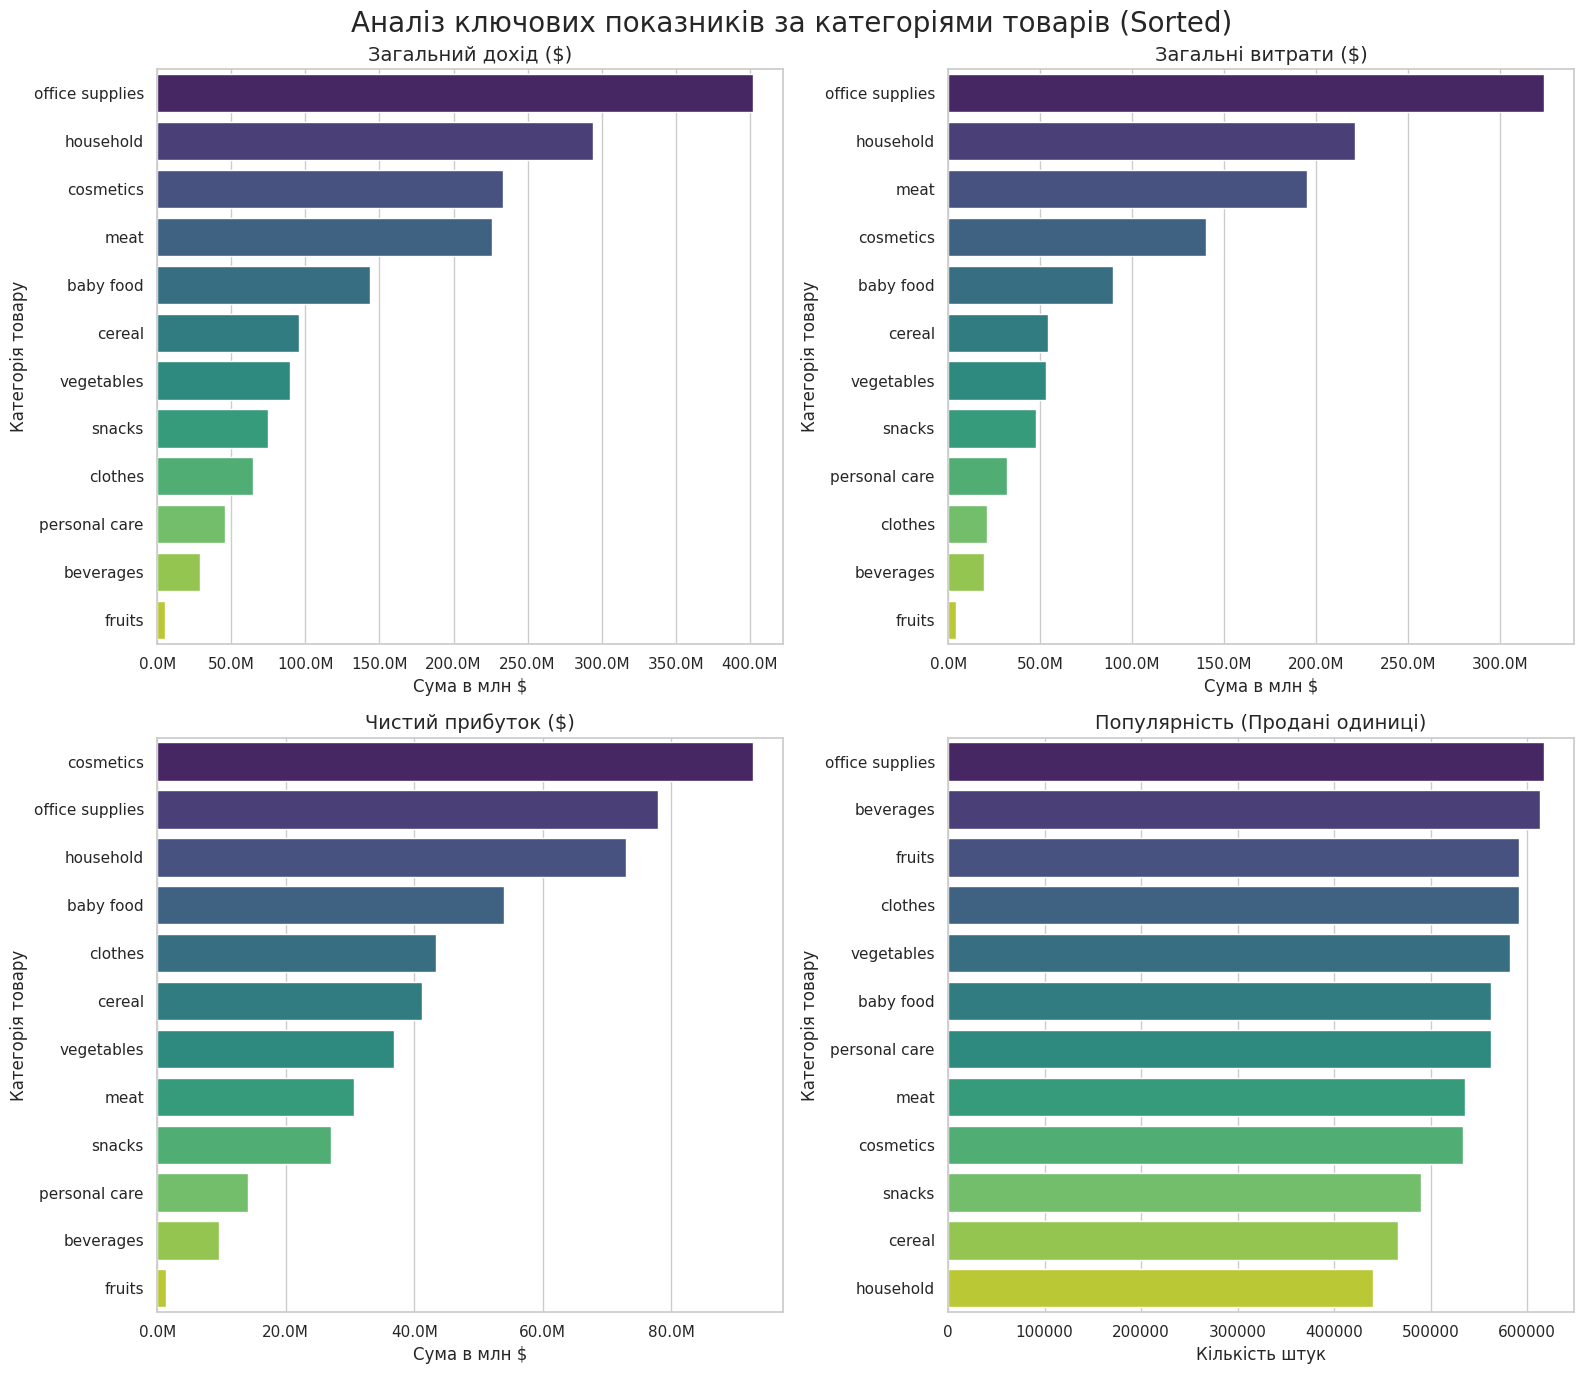

In [ ]:
# Групування даних за категоріями
cat_analysis = sales.groupby('item_type')[['revenue', 'total_cost', 'profit', 'units_sold']].sum().sort_values(by='profit', ascending=False).reset_index()

# Налаштування стилю та створення сітки 2x2
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Аналіз ключових показників за категоріями товарів (Sorted)', fontsize=20)

# Функція для форматування фінансових осей у мільйони
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# 1. Доходи (Revenue) - Сортування за доходом
rev_data = cat_analysis.sort_values('revenue', ascending=False)
sns.barplot(ax=axes[0, 0], data=rev_data, x='revenue', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[0, 0].set_title('Загальний дохід ($)', fontsize=14)
axes[0, 0].xaxis.set_major_formatter(formatter)
axes[0, 0].set_xlabel('Сума в млн $')
axes[0, 0].set_ylabel('Категорія товару')

# 2. Витрати (Total Cost) - Сортування за витратами
cost_data = cat_analysis.sort_values('total_cost', ascending=False)
sns.barplot(ax=axes[0, 1], data=cost_data, x='total_cost', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[0, 1].set_title('Загальні витрати ($)', fontsize=14)
axes[0, 1].xaxis.set_major_formatter(formatter)
axes[0, 1].set_xlabel('Сума в млн $')
axes[0, 1].set_ylabel('Категорія товару')

# 3. Прибутки (Profit) - Сортування за прибутком
profit_data = cat_analysis.sort_values('profit', ascending=False)
sns.barplot(ax=axes[1, 0], data=profit_data, x='profit', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[1, 0].set_title('Чистий прибуток ($)', fontsize=14)
axes[1, 0].xaxis.set_major_formatter(formatter)
axes[1, 0].set_xlabel('Сума в млн $')
axes[1, 0].set_ylabel('Категорія товару')

# 4. Популярність (Units Sold) - Сортування за кількістю одиниць
units_data = cat_analysis.sort_values('units_sold', ascending=False)
sns.barplot(ax=axes[1, 1], data=units_data, x='units_sold', y='item_type', hue='item_type', palette='viridis', legend=False)
axes[1, 1].set_title('Популярність (Продані одиниці)', fontsize=14)
axes[1, 1].set_xlabel('Кількість штук')
axes[1, 1].set_ylabel('Категорія товару')

# Автоматичне коригування розташування для запобігання накладанням
plt.tight_layout()
plt.show()

**Висновки щодо товарних категорій**


*   Найприбутковіший товар - Cosmetics.
Попри низькі обсяги продажів (9-те місце), категорія лідує за чистим прибутком ($90M+), що свідчить про високу маржинальність.

*   Джерело доходу - Office Supplies.
Генерує найбільший виторг ($400M+) та має найбільшу кількість замовлень, але посідає лише 2-ге місце за прибутком через значні витрати.

*   Ефективність - Household.
Показує високий прибуток при мінімальній кількості проданих одиниць - це товар з найвищим середнім чеком

*   Низька маржа - Beverages та Fruits.
Попри величезну популярність, приносять найменше чистого прибутку. Це масові товари, які не є основним джерелом заробітку.

Бізнесу варто фокусуватися на маркетингу косметики та побутових товарів, оскільки вони приносять максимум грошей при мінімальних операційних зусиллях.

###2. Географічний аналіз продажів (Geographic Insights)

У цьому блоці ми дослідимо розподіл фінансових показників за регіонами та країнами. Це допоможе визначити пріоритетні ринки та зони з найвищою маржинальністю.

####2.1. Аналіз за регіонами (Regions)

Порівняємо дохід та прибуток для кожного регіону, а також побачимо частку прибутку на круговій діаграмі.

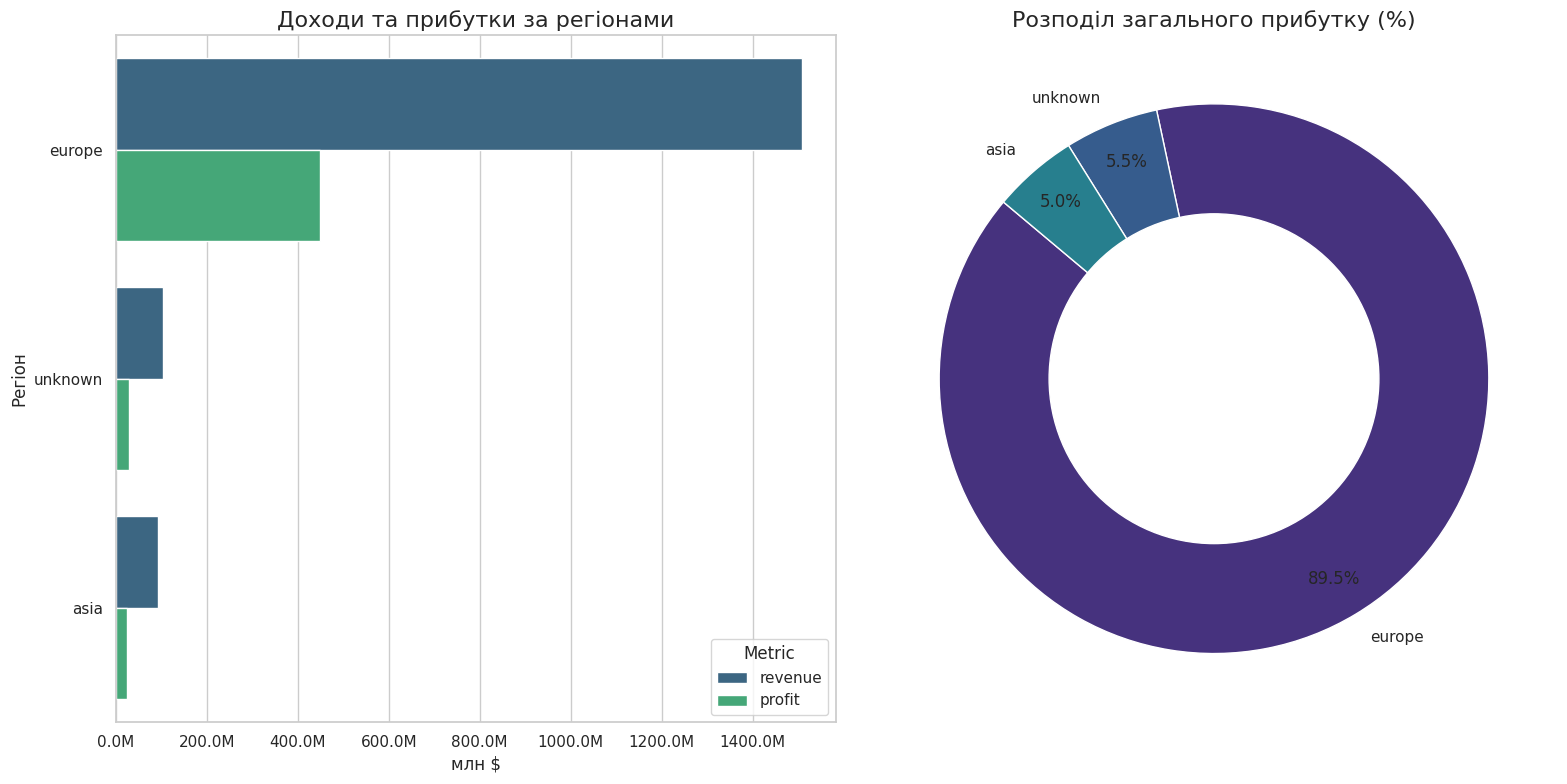

In [ ]:
# Налаштування стилю та створення сітки 1x2
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# Підготовка даних для регіонів (сортування за прибутком)
region_data = sales.groupby('region')[['revenue', 'total_cost', 'profit', 'units_sold']].sum().sort_values('profit', ascending=False).reset_index()

# Графік Дохід vs Прибуток по регіонах
region_melted = region_data.melt(id_vars='region', value_vars=['revenue', 'profit'], var_name='Metric', value_name='Amount')
sns.barplot(ax=axes[0], data=region_melted, x='Amount', y='region', hue='Metric', palette='viridis')
axes[0].set_title('Доходи та прибутки за регіонами', fontsize=16)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].set_xlabel('млн $')
axes[0].set_ylabel('Регіон')

# Кругова діаграма частки прибутку
axes[1].pie(region_data['profit'], labels=region_data['region'], autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('viridis'), pctdistance=0.85)
centre_circle = plt.Circle((0,0), 0.60, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Розподіл загального прибутку (%)', fontsize=16)

plt.tight_layout()
plt.show()

**Висновок:**


*  Домінування Європи: регіон «europe» є абсолютним лідером за всіма показниками. На нього припадає майже 90% від загального прибутку компанії.

*  Висока дохідність: дохід у європейському регіоні перевищує 1400 млн$,
а прибуток становить близько 450 млн$, що свідчить про високу маржинальність порівняно з іншими ринками.

*   Інші регіони: внесок Азії та невідомих регіонів («unknown») є мінімальним - сумарно вони генерують лише 10,5% прибутку. При цьому «unknown» приносить трохи більше прибутку (5,5%), ніж Азія (5,0%), попри подібні обсяги доходу.

Бізнес критично залежить від європейського ринку, який є основним джерелом як доходу, так і чистого прибутку.


####2.2. ТОП-10 країн за ключовими показниками
Подивимось на країни-лідери за прибутком та популярністю товарів (кількістю продажів).

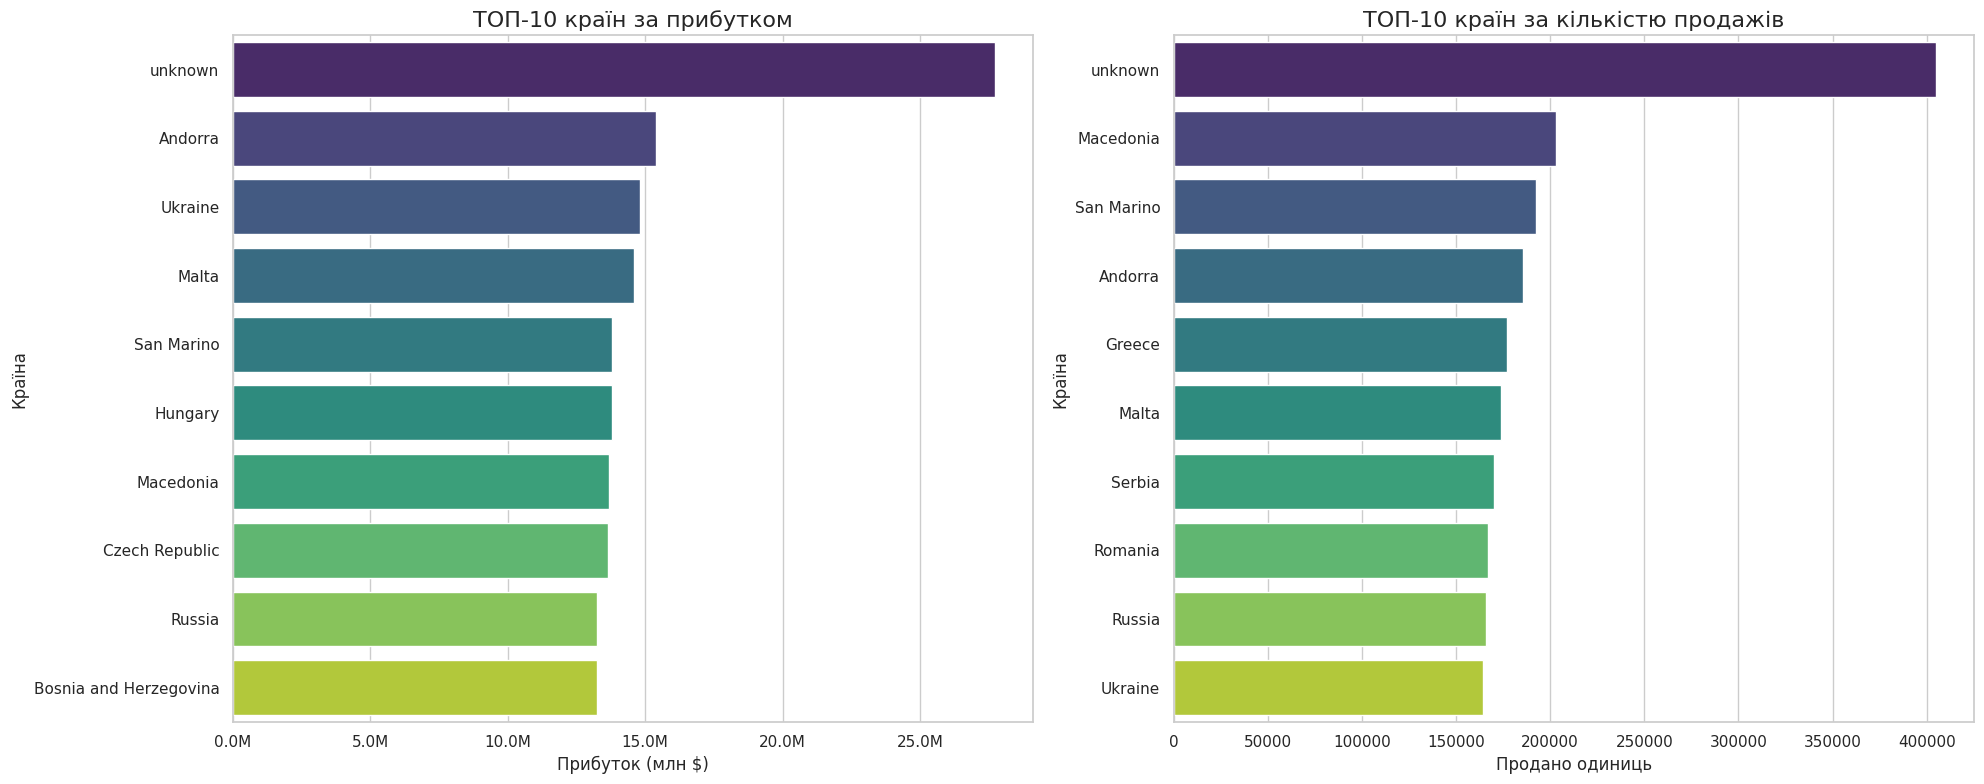

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ТОП-10 країн за прибутком
top_profit_countries = sales.groupby('country_name')['profit'].sum().nlargest(10).reset_index()
sns.barplot(ax=axes[0], data=top_profit_countries, x='profit', y='country_name', hue='country_name', palette='viridis', legend=False)
axes[0].set_title('ТОП-10 країн за прибутком', fontsize=16)
axes[0].xaxis.set_major_formatter(formatter)
axes[0].set_xlabel('Прибуток (млн $)')
axes[0].set_ylabel('Країна')

# ТОП-10 країн за популярністю (кількістю одиниць)
top_units_countries = sales.groupby('country_name')['units_sold'].sum().nlargest(10).reset_index()
sns.barplot(ax=axes[1], data=top_units_countries, x='units_sold', y='country_name', hue='country_name', palette='viridis', legend=False)
axes[1].set_title('ТОП-10 країн за кількістю продажів', fontsize=16)
axes[1].set_xlabel('Продано одиниць')
axes[1].set_ylabel('Країна')

plt.tight_layout()
plt.show()

**Висновок:**

*  Домінування неідентифікованих даних: категорія «unknown» посідає перше місце з величезним відривом, приносячи майже $28 млн прибутку та понад 400 тис. продажів. Це вказує на значний обсяг операцій, де країна не була визначена

*   Лідерство України за маржинальністю: Україна входить у ТОП-3 за прибутком (близько $15 млн), попри те, що за кількістю продажів вона перебуває лише на 10-му місці. Це свідчить про найвищу прибутковість на одиницю товару серед усіх представлених країн.

*   Обсяг проти прибутку: Македонія та Сан-Марино демонструють високі кількісні показники продажів (2-ге та 3-тє місця), проте за чистим прибутком вони поступаються Андоррі та Україні.

*   Стабільність інших ринків: решта країн (Мальта, Угорщина, Чехія, росія) показують відносно рівномірні результати з прибутком у діапазоні $13–15 млн


Ключовим драйвером прибутку є європейський сектор, де український ринок вирізняється високою ефективністю продажів

###3. Аналіз каналів збуту (Sales Channels)
Ми порівняємо канали за чотирма основними метриками: дохід, витрати, чистий прибуток та кількість замовлень.

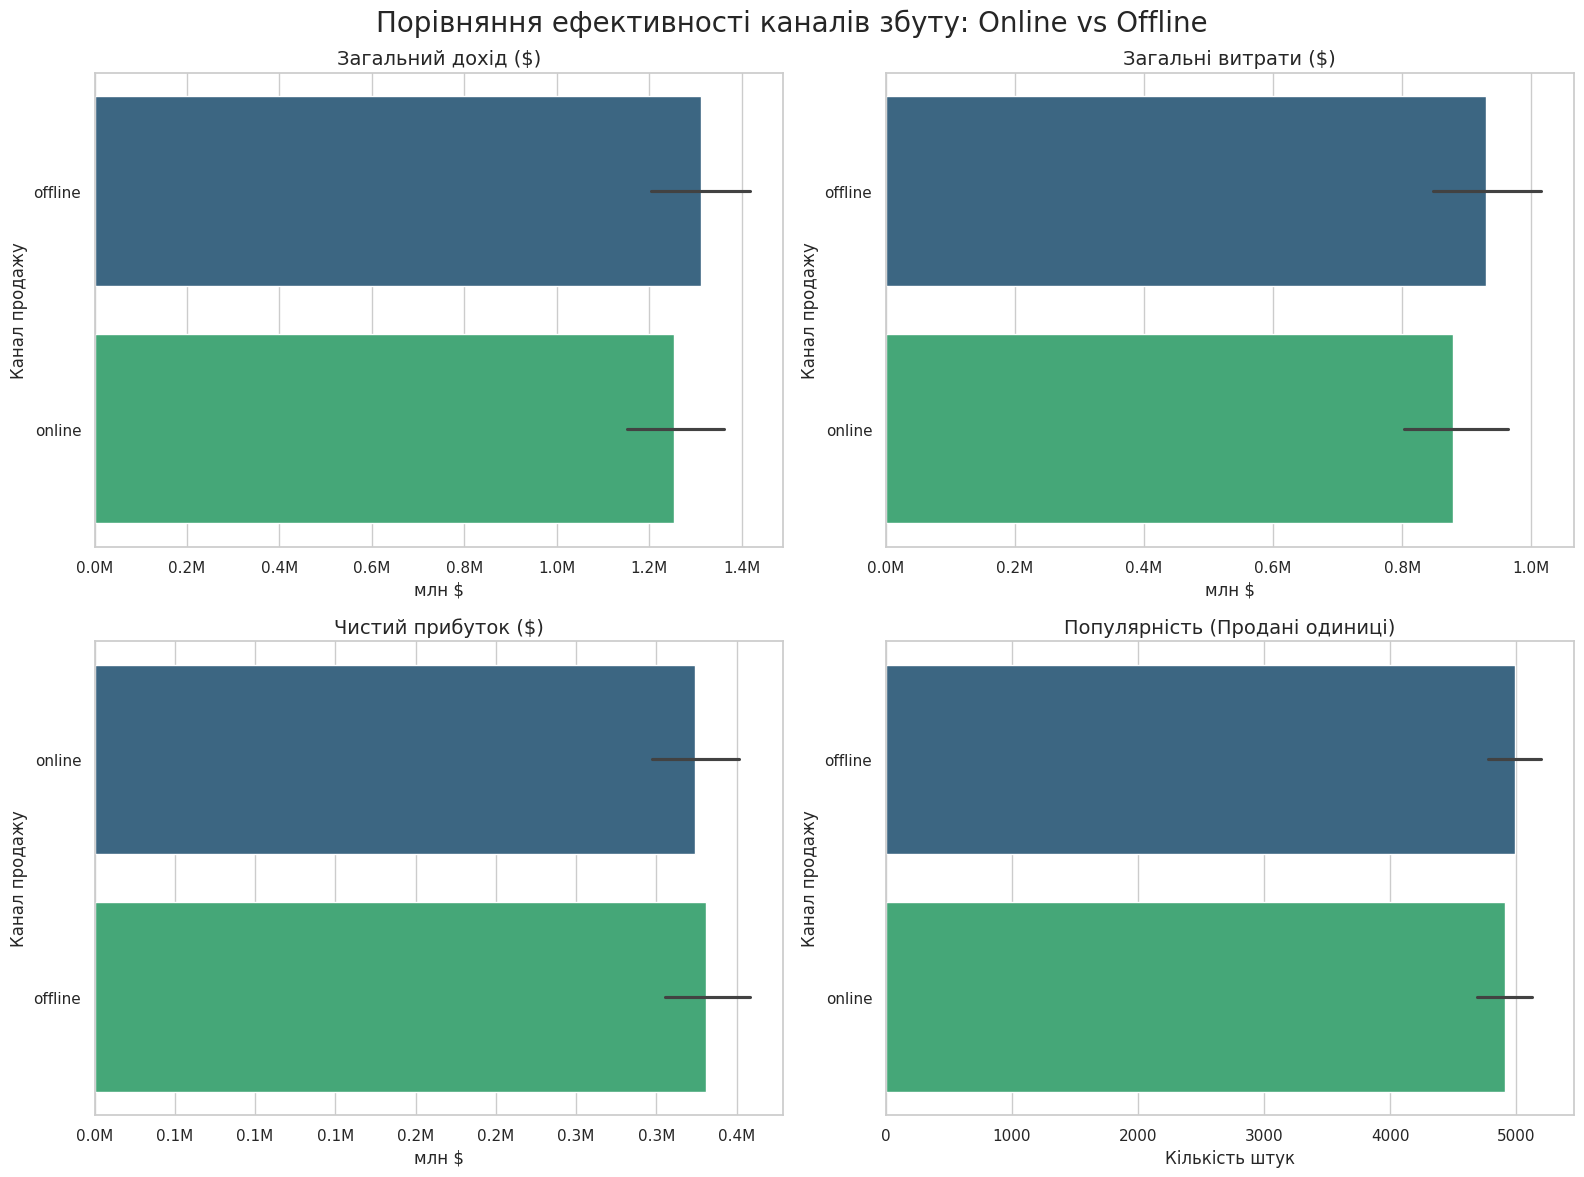

In [ ]:
# Налаштування стилю та створення сітки 2x2
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Порівняння ефективності каналів збуту: Online vs Offline', fontsize=20)

# Форматер для мільйонів
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

# 1. Доходи (Revenue)
sns.barplot(ax=axes[0, 0], data=sales.sort_values('revenue', ascending=False),
            x='revenue', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[0, 0].set_title('Загальний дохід ($)', fontsize=14)
axes[0, 0].xaxis.set_major_formatter(formatter)
axes[0, 0].set_xlabel('млн $')
axes[0, 0].set_ylabel('Канал продажу')

# 2. Витрати (Total Cost)
sns.barplot(ax=axes[0, 1], data=sales.sort_values('total_cost', ascending=False),
            x='total_cost', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[0, 1].set_title('Загальні витрати ($)', fontsize=14)
axes[0, 1].xaxis.set_major_formatter(formatter)
axes[0, 1].set_xlabel('млн $')
axes[0, 1].set_ylabel('Канал продажу')

# 3. Прибутки (Profit)
sns.barplot(ax=axes[1, 0], data=sales.sort_values('profit', ascending=False),
            x='profit', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[1, 0].set_title('Чистий прибуток ($)', fontsize=14)
axes[1, 0].xaxis.set_major_formatter(formatter)
axes[1, 0].set_xlabel('млн $')
axes[1, 0].set_ylabel('Канал продажу')

# 4. Популярність (Units Sold)
sns.barplot(ax=axes[1, 1], data=sales.sort_values('units_sold', ascending=False),
            x='units_sold', y='sales_channel', hue='sales_channel', palette='viridis', legend=False)
axes[1, 1].set_title('Популярність (Продані одиниці)', fontsize=14)
axes[1, 1].set_xlabel('Кількість штук')
axes[1, 1].set_ylabel('Канал продажу')

plt.tight_layout()
plt.show()

**Висновок:**

*   Офлайн переважає за всіма показниками: доходом, прибутком та кількістю продажів. Це основний фундамент бізнесу.

*   Попри вищі витрати (приблизно $0.9M), офлайн генерує вищий чистий прибуток ($0.35M+), що свідчить про його високу ефективність.

*   Офлайн має більшу інтенсивність продажів (>4500 од.), хоча онлайн-канал тримається близько (4400 од.).

*   Мінімальний розрив між каналами вказує на те, що бізнес успішно диверсифікує ризики

Офлайн зараз приносить основні гроші, але онлайн має потенціал до масштабування за умови оптимізації логістичних витрат.

##Аналіз залежності прибутку від швидкості відвантаження

У цьому розділі ми перевіримо гіпотезу: чи впливає тривалість логістичних процесів на фінансовий результат замовлення.

In [ ]:
# Розрахунок середнього прибутку для кожної тривалості відвантаження
profit_by_days = sales.groupby('order_processing')['profit'].mean().reset_index()

# Обчислення кореляції Пірсона
correlation = sales['order_processing'].corr(sales['profit'])
print(f"Кореляція між часом відвантаження та прибутком: {correlation:.4f}")

Кореляція між часом відвантаження та прибутком: 0.0607


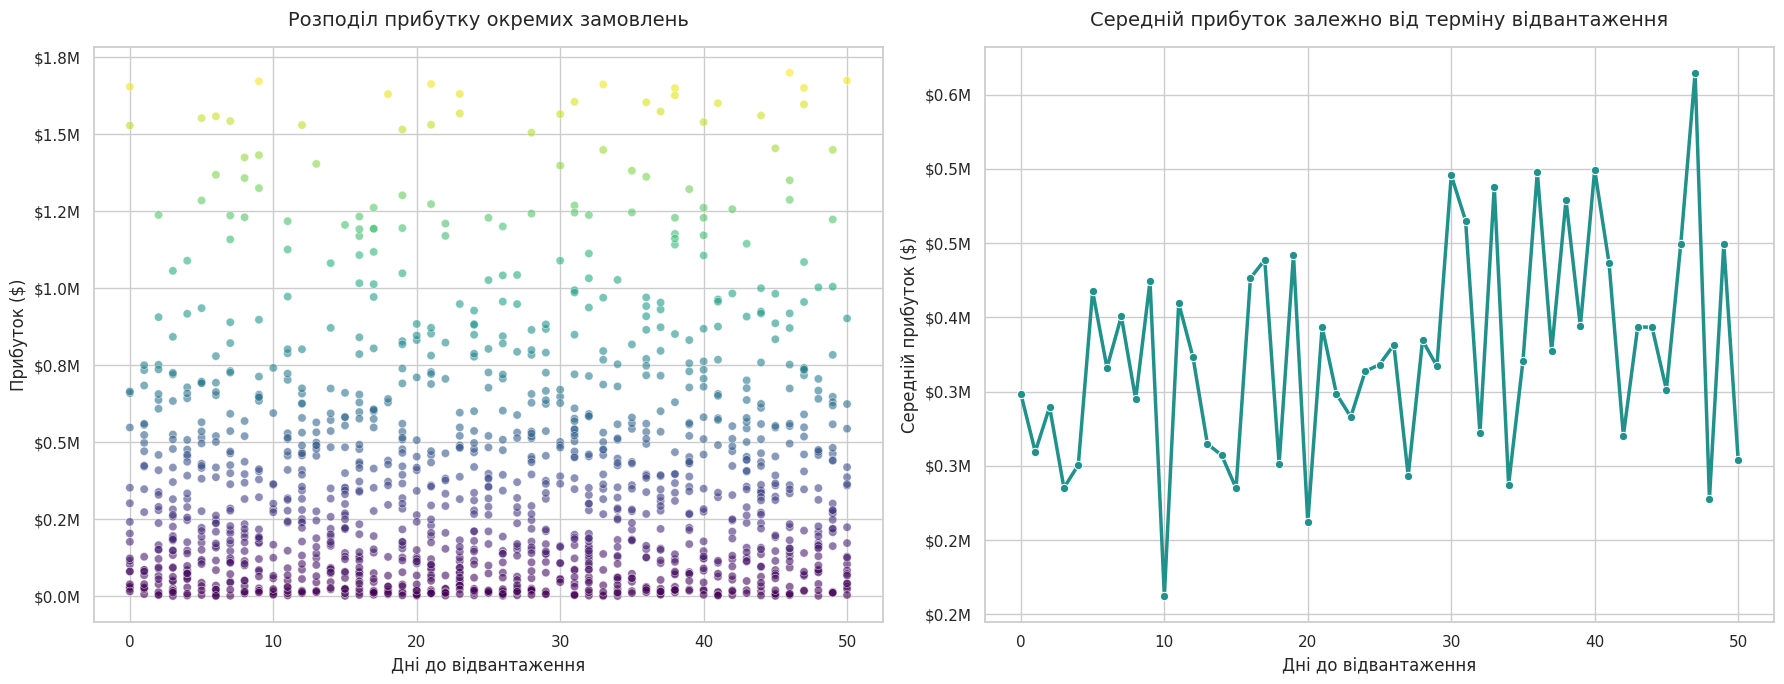

In [ ]:
# Налаштування стилю
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Форматер для вісі y
million_formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')

# Scatter Plot
sns.scatterplot(ax=axes[0], data=sales, x='order_processing', y='profit',
                hue='profit', palette='viridis', alpha=0.6, legend=False)
axes[0].set_title('Розподіл прибутку окремих замовлень', fontsize=14, pad=15)
axes[0].set_xlabel('Дні до відвантаження')
axes[0].set_ylabel('Прибуток ($)')
axes[0].yaxis.set_major_formatter(million_formatter)

# Line Plot
sns.lineplot(ax=axes[1], data=profit_by_days, x='order_processing', y='profit',
             marker='o', color='#21918c', linewidth=2.5)
axes[1].set_title('Середній прибуток залежно від терміну відвантаження', fontsize=14, pad=15)
axes[1].set_xlabel('Дні до відвантаження')
axes[1].set_ylabel('Середній прибуток ($)')
axes[1].yaxis.set_major_formatter(million_formatter)

plt.tight_layout()
plt.show()

**Вплив терміну відвантаження на прибутковість**

Аналіз продемонстрував, що швидкість відвантаження товарів не має прямого впливу на фінансовий результат замовлень.

*   Коефіцієнт кореляції Пірсона становить приблизно 0.06. Це критично низьке значення, яке математично підтверджує відсутність зв'язку між часом очікування та сумою прибутку.

*   На діаграмі розсіюванн ми бачимо, що замовлення з високим прибутком (понад $1.5M) трапляються як на 1-й, так і на 50-й день очікування. Немає жодної тенденції до зниження прибутку при тривалій обробці.

*   Графік тренду середнього прибутку хоч і має значні коливання, але вони мають хаотичний характер і не демонструють вираженого зростання або спадання.

Оскільки прибуток не страждає від затримок, бізнес має можливість зосередитися на якості сервісу. Хоча швидкість не приносить більше грошей напряму, вона впливає на задоволеність клієнтів та ймовірність повторних покупок. Логістичне плече до 50 днів є безпечним для поточної фінансової моделі.

##Аналіз динаміки продажів у часі (Time Series Analysis)


У цьому розділі ми проводимо комплексне дослідження часових рядів, щоб відстежити еволюцію доходів компанії. Аналіз охоплює три рівні деталізації: географічні регіони, ключові країни-партнери та категорії товарів. Такий підхід дозволяє ідентифікувати приховану сезонність, періодичність великих контрактів та драйвери прибутку, що формують фінансовий результат у різні роки.

###1. Аналіз динаміки продажів у ключових регіонах (Time Series)


Цей розділ присвячений детальному дослідженню того, як змінювалися обсяги продажів та дохід компанії від місяця до місяця у двох найбільших регіонах: Азії та Європі. Це дозволить виявити сезонні піки, аномалії та загальний тренд розвитку бізнесу.

In [ ]:
# Конвертуємо дати та створюємо колонку місяця
sales['order_date'] = pd.to_datetime(sales['order_date'])
sales['month_year'] = sales['order_date'].dt.to_period('M').astype(str)

# Рахуємо дохід, якщо його немає
if 'revenue' not in sales.columns:
    sales['revenue'] = sales['units_sold'] * sales['unit_price']

# Групуємо дані один раз для всього аналізу
monthly_sales = sales.groupby(['month_year', 'region']).agg({'units_sold': 'sum', 'revenue': 'sum'}).reset_index()


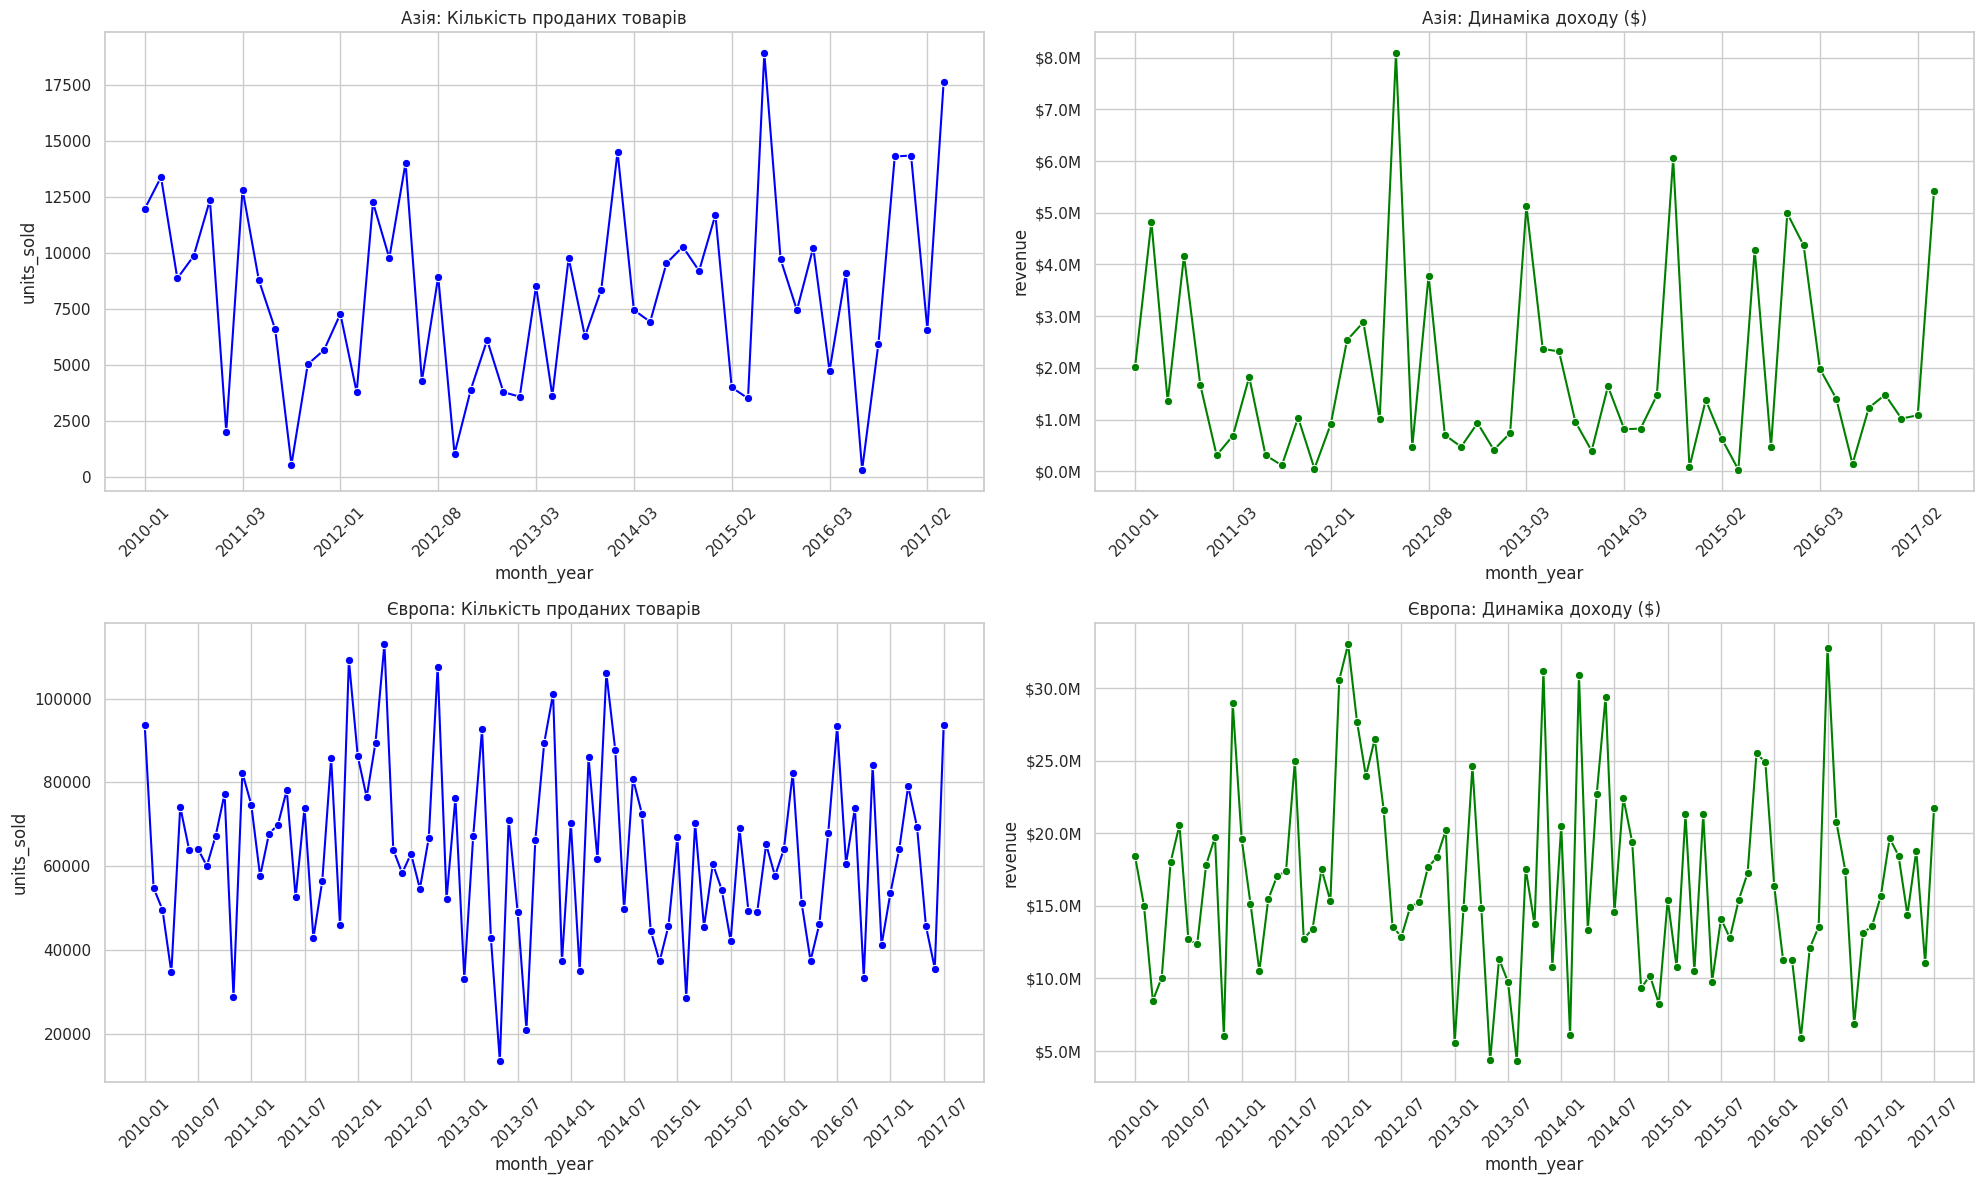

In [ ]:
# Налаштування загального стилю
plt.figure(figsize=(20, 12))
sns.set_theme(style="whitegrid")

# Форматер для перетворення чисел у формат мільйонів доларів
# x/1e6 ділить число на мільйон, а .1f залишає один знак після коми
money_formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')

# Отримуємо унікальний список всіх місяців, відсортований за часом
all_months = sorted(monthly_sales['month_year'].unique())

# Зробимо функцію для того, щоб не писати код в кожному графіку
def fix_x_axis(ax):
    # Показувати кожен 6-й підпис (раз на пів року), щоб не було нагромадження
    ax.xaxis.set_major_locator(ticker.IndexLocator(base=6, offset=0))
    ax.tick_params(axis='x', rotation=45)

# --- АЗІЯ ---
# 1. Кількість (Asia)
ax1 = plt.subplot(2, 2, 1)
asia_data = monthly_sales[monthly_sales['region'] == 'asia']
sns.lineplot(data=asia_data, x='month_year', y='units_sold', marker='o', color='blue')
plt.title('Азія: Кількість проданих товарів')
fix_x_axis(ax1)

# 2. Дохід (Asia)
ax2 = plt.subplot(2, 2, 2)
sns.lineplot(data=asia_data, x='month_year', y='revenue', marker='o', color='green')
plt.title('Азія: Динаміка доходу ($)')
ax2.yaxis.set_major_formatter(money_formatter)
fix_x_axis(ax2)

# --- ЄВРОПА ---
# 3. Кількість (Europe)
ax3 = plt.subplot(2, 2, 3)
europe_data = monthly_sales[monthly_sales['region'] == 'europe']
sns.lineplot(data=europe_data, x='month_year', y='units_sold', marker='o', color='blue')
plt.title('Європа: Кількість проданих товарів')
fix_x_axis(ax3)

# 4. Дохід (Europe)
ax4 = plt.subplot(2, 2, 4)
sns.lineplot(data=europe_data, x='month_year', y='revenue', marker='o', color='green')
plt.title('Європа: Динаміка доходу ($)')
ax4.yaxis.set_major_formatter(money_formatter)
fix_x_axis(ax4)

plt.tight_layout()
plt.show()

**Аналіз динаміки продажів та основні тенденції**

На основі візуалізації часових рядів для регіонів Азія та Європа можна виділити такі ключові тренди:

1. Висока волатильність та відсутність сезонності

Продажі в обох регіонах демонструють значні коливання від місяця до місяця. На графіках не спостерігається чіткої щорічної сезонності. Це характерно для моделі B2B або великих гуртових поставок, де фінансовий результат залежить від закриття конкретних великих контрактів, а не від роздрібного попиту.

2. Масштаб ринків


*   Європа є значно більшим ринком за обсягами: дохід тут коливається в межах $5M – $30M+ на місяць, а кількість проданих одиниць сягає 110,000+.
*   Азія демонструє скромніші показники: місячний дохід переважно становить $1M – $8M, а обсяги продажів рідко перевищують 17,500 одиниць.

3. Кореляція обсягів та доходу

В обох регіонах графіки кількості (units_sold) та доходу (revenue) практично ідентичні за формою. Це означає, що:

*   Зростання прибутку відбувається за рахунок збільшення кількості проданого товару, а не за рахунок зміни цін.
*   Середній чек замовлень залишається стабільним протягом усього періоду.

4. Аномальні піки (Драйвери росту)


*   В Азії спостерігається аномальний стрибок на початку 2012 року та в середині 2015-го.
*   В Європі піковими періодами стали початок 2012, 2014 та середина 2016 років.
Ці сплески генерують основну частину річного прибутку, тому важливо проаналізувати, які саме категорії товарів або країни забезпечили ці продажі.

Бізнес має стійкий, але нестабільний характер продажів. Європа залишається стратегічним пріоритетом за обсягами, тоді як Азія виступає як додатковий ринок з меншою інтенсивністю. Для стабілізації доходів варто розглянути можливість диверсифікації товарного портфеля, щоб згладити місячні падіння.

###2. Аналіз динаміки продажів у розрізі ключових країн


Для детального дослідження ринкової активності було побудовано теплову карту доходів у розрізі десяти ключових країн-партнерів. На відміну від лінійних графіків, такий підхід дозволяє нівелювати візуальний шум від перетину ліній і чітко зафіксувати місяці з аномально високими показниками продажів. Дані для аналізу були попередньо очищені від записів з невизначеною локацією (unknown).

In [ ]:
# Відфільтровуємо unknown та беремо ТОП-10 країн за доходом
top_countries_list = sales[sales['country_name'] != 'unknown'].groupby('country_name')['revenue'].sum().nlargest(10).index
df_heatmap = sales[sales['country_name'].isin(top_countries_list)].copy()

# Готуємо колонку Year-Month
df_heatmap['month_year'] = df_heatmap['order_date'].dt.to_period('M').astype(str)

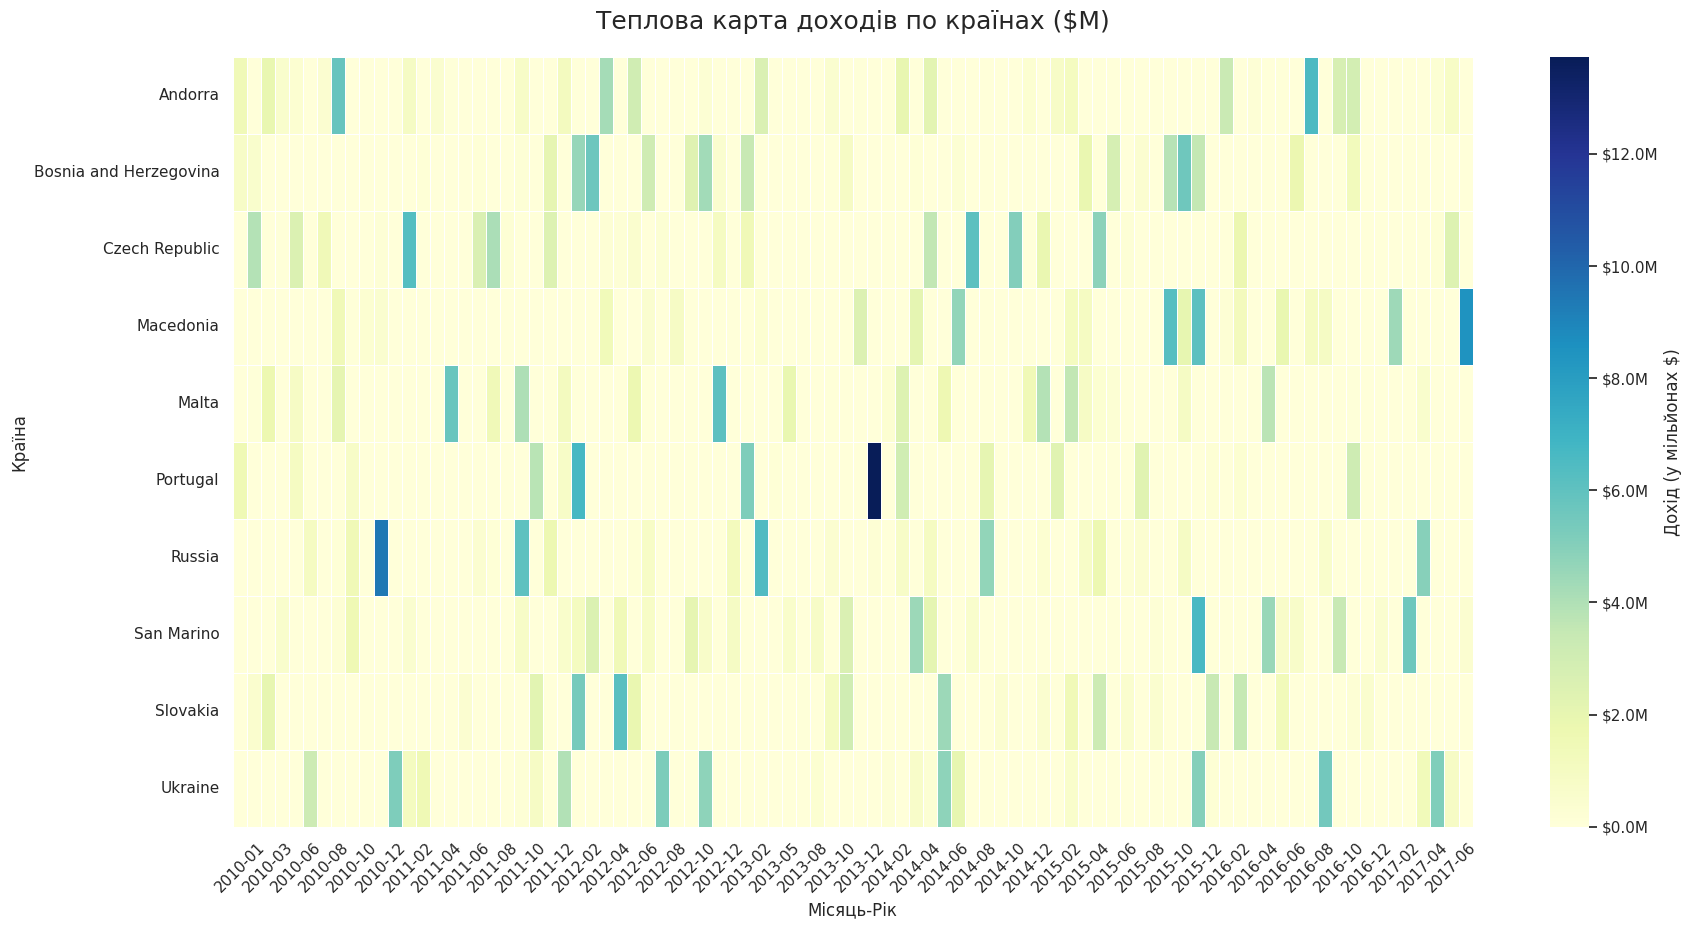

In [ ]:
# Готуємо матрицю (переконаємося, що unknown видалено)
pivot_df = df_heatmap[df_heatmap['country_name'] != 'unknown'].pivot_table(
    index='country_name',
    columns='month_year',
    values='revenue',
    aggfunc='sum',
    fill_value=0)

# Малюємо Heatmap
plt.figure(figsize=(20, 10))

# Налаштовуємо колірну шкалу через cbar_kws
ax = sns.heatmap(pivot_df,
            cmap="YlGnBu",
            linewidths=.5,
            cbar_kws={
                'label': 'Дохід (у мільйонах $)',
                'format': ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')})
plt.title('Теплова карта доходів по країнах ($M)', fontsize=18, pad=20)
plt.xlabel('Місяць-Рік', fontsize=12)
plt.ylabel('Країна', fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Аналіз географічної динаміки доходів**

Теплова карта дозволила виявити ключові закономірності, які були приховані на лінійних графіках:


*   Проєктний характер продажів: доходи мають "плямисту" структуру. Це свідчить про роботу з великими разовими контрактами, а не про стабільний щомісячний попит.
*   Критичні драйвери (Аномалії): чітко виділяється Португалія (кінець 2013) з рекордним доходом понад $13M за місяць, а також сплеск у росії (кінець 2010). Ці одиничні транзакції сформували значну частину прибутку періоду
*   Стабільність ринків: Україна та Чехія демонструють найбільш регулярні замовлення. Попри менші суми, ці країни забезпечують прогнозований грошовий потік
*   Глобальні паузи: виявлено періоди (наприклад, середина 2013-го), коли активність падала синхронно на всіх ринках, що вказує на вплив зовнішніх факторів.


###3.Аналіз динаміки продажів за категоріями товарів

Для глибшого розуміння структури прибутку було проаналізувано динаміку доходів у розрізі категорій товарів за весь період спостереження. Використання теплової карти дозволяє відійти від нагромадження ліній і чітко побачити, які саме групи товарів формують фінансову основу компанії, а які мають сезонний або епізодичний характер продажів. Кожна клітинка графіка відображає сумарний дохід конкретної категорії за певний місяць.

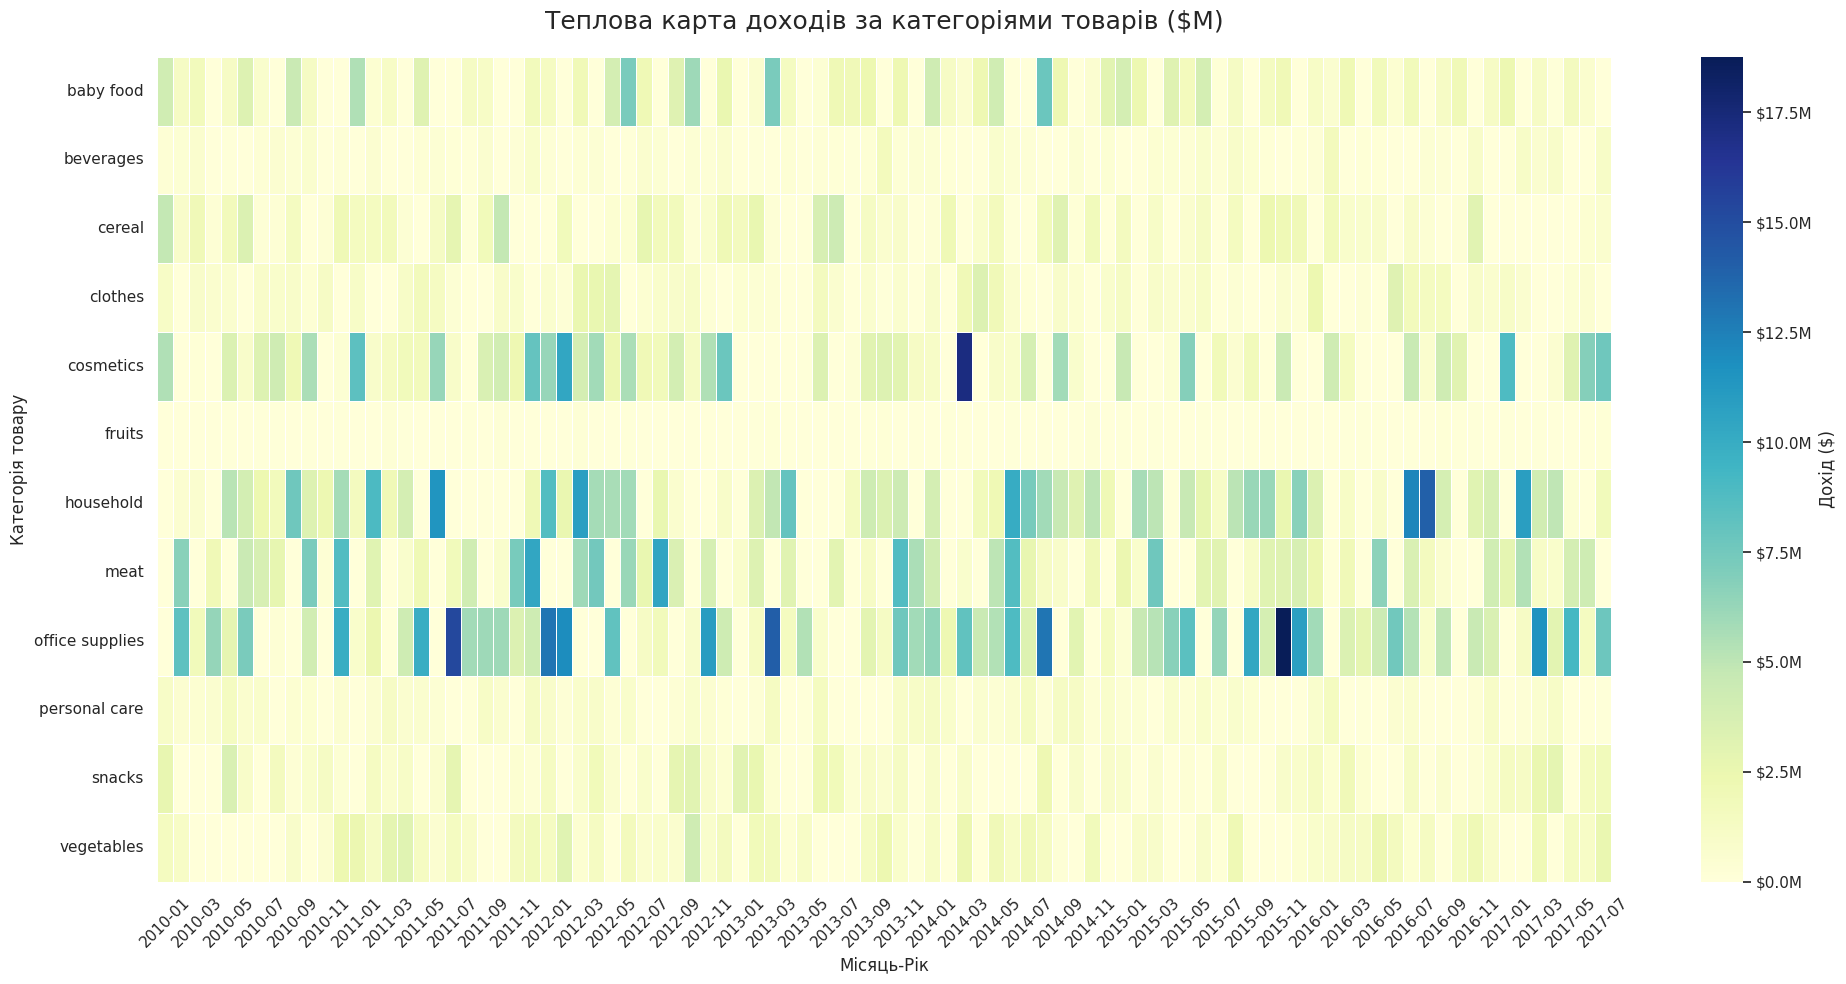

In [ ]:
# Готуємо матрицю: Категорія vs Місяць
category_pivot = sales.pivot_table(
    index='item_type',
    columns=sales['order_date'].dt.to_period('M').astype(str),
    values='revenue',
    aggfunc='sum',
    fill_value=0)

# Візуалізація
plt.figure(figsize=(20, 10))

sns.heatmap(category_pivot,
            cmap="YlGnBu",
            linewidths=.5,
            cbar_kws={
                'label': 'Дохід ($)',
                'format': ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')})

plt.title('Теплова карта доходів за категоріями товарів ($M)', fontsize=18, pad=20)
plt.xlabel('Місяць-Рік', fontsize=12)
plt.ylabel('Категорія товару', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Аналіз динаміки доходів по категоріям товарів**


*   Стабільні драйвери доходу: Категорії Household, Office Supplies та Cosmetics демонструють найбільш стабільну та інтенсивну забарвленість протягом усього часу. Це ключові сегменти, які забезпечують регулярний грошовий потік компанії.

*   Відсутність вузької спеціалізації: на карті видно, що компанія успішно реалізує широкий спектр товарів - від харчових продуктів до промислових товарів. Така диверсифікація знижує ризики при падінні попиту в одному з сегментів.

*   Низька сезонна залежність: більшість категорій не мають яскраво виражених «порожніх» місяців, що свідчить про налагоджені ланцюжки збуту, які працюють незалежно від пори року.









##Аналіз циклічності за днями тижня та сезонності продажів

У цьому розділі ми досліджуємо ритм компанії: як продажі розподіляються всередині тижня та протягом календарного року. Це дозволяє виявити приховані закономірності та визначити товари з вираженою залежністю від календарного періоду.

###1. Аналіз продажу товарів за днями тижня

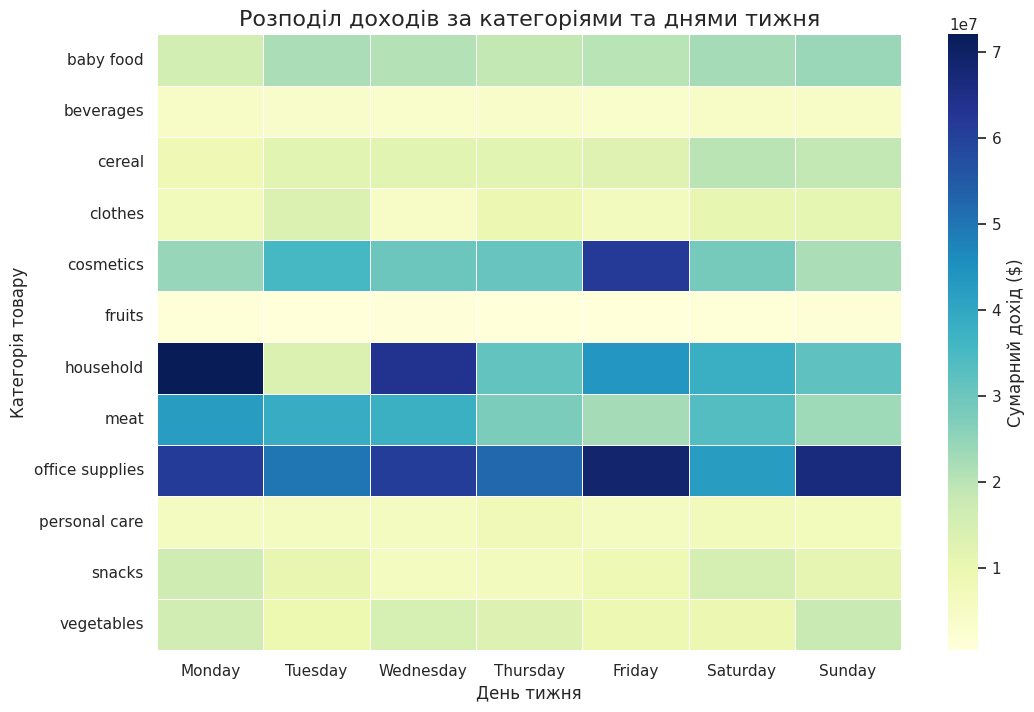

In [ ]:
# Додаємо назву дня тижня
sales['day_of_week'] = sales['order_date'].dt.day_name()

# Впорядковуємо дні тижня хронологічно
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Створюємо матрицю: Категорія vs День тижня
weekday_pivot = sales.pivot_table(
    index='item_type',
    columns='day_of_week',
    values='revenue',
    aggfunc='sum'
).reindex(columns=days_order)

# Візуалізація
plt.figure(figsize=(12, 8))
sns.heatmap(weekday_pivot, cmap="YlGnBu", annot=False, linewidths=.5,
            cbar_kws={'label': 'Сумарний дохід ($)'})

plt.title('Розподіл доходів за категоріями та днями тижня', fontsize=16)
plt.xlabel('День тижня')
plt.ylabel('Категорія товару')
plt.show()

###2. Сезонність товарів

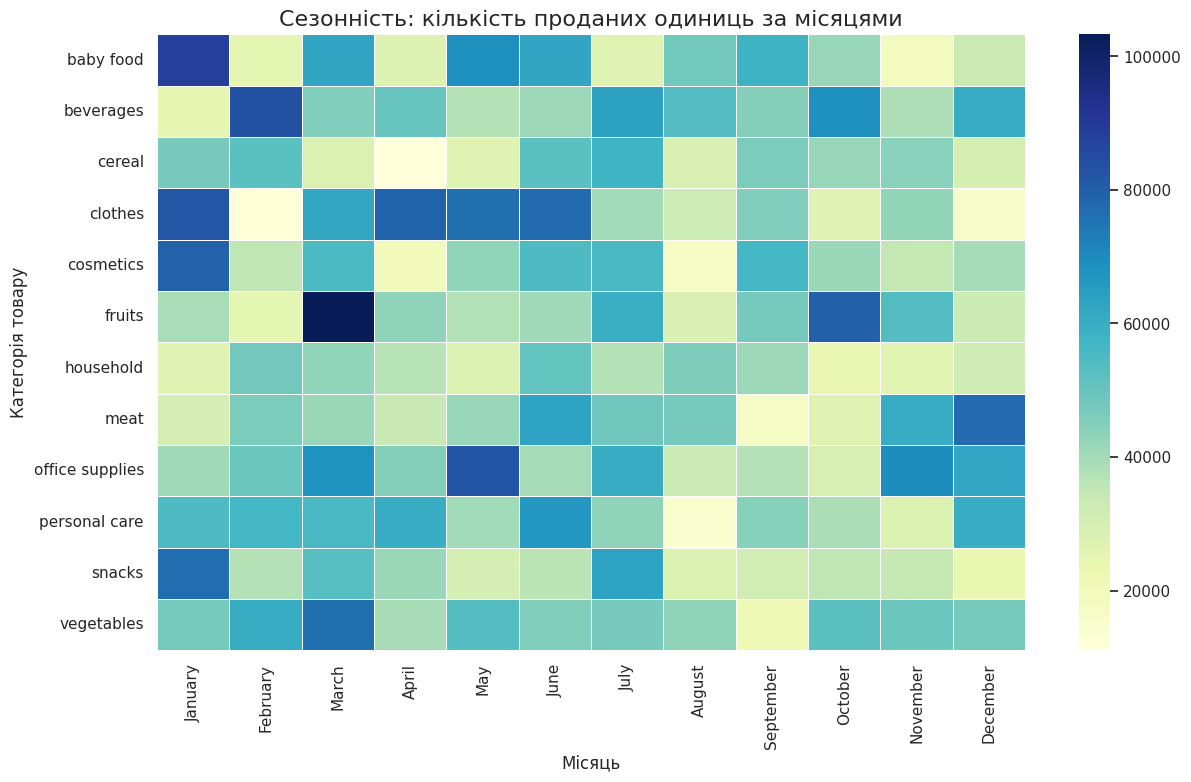

In [ ]:
# Додаємо назву місяця
sales['month'] = sales['order_date'].dt.month_name()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

# Матриця сезонності
seasonality_pivot = sales.pivot_table(
    index='item_type',
    columns='month',
    values='units_sold',
    aggfunc='sum'
).reindex(columns=months_order)

# Візуалізація
plt.figure(figsize=(14, 8))
sns.heatmap(seasonality_pivot, cmap="YlGnBu", linewidths=.5)
plt.title('Сезонність: кількість проданих одиниць за місяцями', fontsize=16)
plt.xlabel('Місяць')
plt.ylabel('Категорія товару')
plt.show()

**Результати аналізу циклічності та сезонності**


**1. Тижневі цикли**


*   Рівномірність: більшість категорій (наприклад, Meat, Cereal, Personal Care) демонструють стабільний дохід протягом тижня. Це вказує на відсутність специфічних найбільш популярних днів і потребу в рівномірному завантаженні персоналу.
*   Пікові дні: на тепловій карті помітно, що категорія Household має найвищу активність у понеділок та середу, тоді як Cosmetics та Office Supplies демонструють сплески у п'ятницю.

**2. Сезонні коливання**


*   Виражена сезонність: категорія Fruits має аномальний пік у березні та жовтні, що, ймовірно, пов’язано з регіональними циклами врожаю. Clothes та Baby Food демонструють високу активність на початку року (січень–травень), що може свідчити про великі закупівлі на старті нових сезонів.

*   Стабільні групи: Vegetables та Household залишаються відносно стабільними протягом року, виступаючи надійним базисом для загального обсягу продажів компанії.
*   Логістичне планування: виявлено низький попит у певних категоріях у літні місяці (наприклад, Baby Food у серпні) дозволяють планувати технічне обслуговування складів або ротацію асортименту без втрати критичного прибутку.


Бізнес має змішану модель: стабільні щоденні продажі базових товарів поєднуються з яскраво вираженими сезонними сплесками в продуктових групах.